# Fitting Rotation Curves

## Import packages

In [1]:
import scipy.interpolate as spl
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
import scipy.integrate as spint
from scipy.optimize import curve_fit
import csv
from warnings import catch_warnings, simplefilter
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import odr
import matplotlib.cm as cm

In [2]:
# Set your data locations here
datadir = "../data/"
outdir = "../outputs/"

sparc = pd.read_csv(datadir+'SPARC_Lelli2016c.mrt.csv')
directory2 = datadir+"SPARC_rotcurves_mod/"
gab_names = np.array(sparc['Name'][np.where(np.array(sparc['Vflat'].tolist()) != 0)[0]].tolist())
# mask inclination to only keep galaxies >40 and <80 degrees
gab_names_finc = np.array(sparc['Name'].values[np.where((np.array(sparc['Inc'].values) >= 40) & (np.array(sparc['Inc'].values) <= 79))[0]])

In [3]:
gab_names_finc

array(['CamB', 'D512-2', 'D564-8', 'D631-7', 'DDO064', 'DDO154', 'DDO161',
       'DDO168', 'DDO170', 'ESO079-G014', 'ESO116-G012', 'F563-V1',
       'F565-V2', 'F568-3', 'F568-V1', 'F574-1', 'F583-1', 'F583-4',
       'IC2574', 'KK98-251', 'NGC0024', 'NGC0055', 'NGC0247', 'NGC0289',
       'NGC0300', 'NGC1003', 'NGC1090', 'NGC2366', 'NGC2403', 'NGC2841',
       'NGC2903', 'NGC2915', 'NGC2955', 'NGC2976', 'NGC2998', 'NGC3109',
       'NGC3198', 'NGC3521', 'NGC3726', 'NGC3741', 'NGC3769', 'NGC3877',
       'NGC3893', 'NGC3917', 'NGC3949', 'NGC3953', 'NGC3972', 'NGC3992',
       'NGC4051', 'NGC4068', 'NGC4088', 'NGC4100', 'NGC4138', 'NGC4389',
       'NGC4559', 'NGC5005', 'NGC5033', 'NGC5055', 'NGC5371', 'NGC5585',
       'NGC5985', 'NGC6015', 'NGC6195', 'NGC6503', 'NGC6674', 'NGC6789',
       'NGC7331', 'NGC7793', 'PGC51017', 'UGC00128', 'UGC00191',
       'UGC00731', 'UGC00891', 'UGC02259', 'UGC02455', 'UGC02885',
       'UGC02916', 'UGC02953', 'UGC03205', 'UGC03546', 'UGC03580',
     

In [4]:
# pd.set_option("display.max_rows", 200)
# pd.set_option("display.max_columns", 50)

In [5]:
def tanh(x, vf, rv):
    return vf*np.tanh(x/rv)

def boissier(r, wc, rv):
    return wc*(1-np.exp(-r/rv))

def _clean_rc(df):
    """Return sorted, cleaned (r, v, ev) numpy arrays."""
    r = pd.to_numeric(df['Rad[kpc]'], errors='coerce').to_numpy()
    v = pd.to_numeric(df['Vobs[km/s]'], errors='coerce').to_numpy()
    ev = pd.to_numeric(df['errV[km/s]'], errors='coerce').to_numpy()

    # finite, non-negative radii; finite velocities and errors
    m = np.isfinite(r) & np.isfinite(v) & np.isfinite(ev) & (r >= 0)
    r, v, ev = r[m], v[m], ev[m]
    if r.size:
        order = np.argsort(r)
        r, v, ev = r[order], v[order], ev[order]
    # avoid zero/near-zero uncertainties
    ev = np.where(ev <= 0, np.nan, ev)
    # if all errors invalid, fall back to unweighted later
    return r, v, ev

def _initial_guesses(r, v):
    """Data-driven initial guesses; fall back to your old [150, 1] if needed."""
    if len(r) == 0 or len(v) == 0:
        return 150.0, 1.0
    vf0 = float(np.nanpercentile(v, 90)) if np.isfinite(np.nanpercentile(v, 90)) else 150.0
    R  = float(np.nanmax(r)) if np.isfinite(np.nanmax(r)) and np.nanmax(r) > 0 else 1.0
    rv0 = max(0.2, 0.4 * R)
    return vf0, rv0

def _fit_model(model_fn, r, v, ev, p0, bounds):
    """Try weighted fit first; on failure retry unweighted; returns (p, perr) or (nan)."""
    # try weighted fit
    use_weight = np.isfinite(ev).sum() >= max(3, len(ev)//3)
    try_p0 = p0
    for attempt in range(3):
        try:
            with catch_warnings():
                simplefilter("ignore")  # suppress OptimizeWarning etc.
                if use_weight:
                    popt, pcov = curve_fit(model_fn, r, v, sigma=ev, p0=try_p0,
                                           bounds=bounds, absolute_sigma=True, maxfev=200000)
                else:
                    popt, pcov = curve_fit(model_fn, r, v, p0=try_p0,
                                           bounds=bounds, maxfev=200000)
            perr = np.sqrt(np.diag(pcov))
            # sanity: if covariance exploded, mark as nan so we can retry
            if not np.all(np.isfinite(perr)):
                raise RuntimeError("non-finite covariance")
            return popt, perr
        except Exception:
            # second attempt: unweighted if weighted failed, or new p0
            use_weight = False
            # refresh p0 from current data (guard against stuck start)
            try_p0 = _initial_guesses(r, v)
    # failed all attempts
    return np.array([np.nan, np.nan]), np.array([np.nan, np.nan])

## Fit

In [6]:
param_list_SPARC_tanh = []
param_list_SPARC_boissier = []
i=0

show_plots = False
for filename in os.listdir(directory2):
    if not filename.endswith(".dat"):
        continue
    filepath = os.path.join(directory2, filename)
    galaxy = os.path.splitext(filename)[0].split('_')[0]

    if galaxy not in gab_names_finc:
        # keep the exact logging style you had
        print(galaxy + " not in the original SPARC dataset\n")
        continue

    #print(galaxy + " in the original SPARC dataset\n")
    df_SPARC = pd.read_table(filepath, sep="\t", usecols=["Rad[kpc]", "Vobs[km/s]", "errV[km/s]"])
    r, v, v_e = _clean_rc(df_SPARC)

    # require enough data to constrain two-parameter models
    if len(r) < 5 or len(v) < 5:
        param_list_SPARC_tanh.append((galaxy, np.nan, np.nan, np.nan, np.nan))
        param_list_SPARC_boissier.append((galaxy, np.nan, np.nan, np.nan, np.nan))
        continue

    # initial guesses and bounds (strictly positive vf, rv)
    p0 = _initial_guesses(r, v)
    bounds = ([1.0, 1e-3], [1000.0, 100.0])

    # tanh fit
    tpopt, tperr = _fit_model(tanh, r, v, v_e, p0=p0, bounds=bounds)
    tvf, trv = tpopt
    tvf_e, trv_e = tperr if np.all(np.isfinite(tperr)) else (np.nan, np.nan)
    param_list_SPARC_tanh.append((galaxy, tvf, tvf_e, trv, trv_e))

    # boissier fit
    bpopt, bperr = _fit_model(boissier, r, v, v_e, p0=p0, bounds=bounds)
    bvf, brv = bpopt
    bvf_e, brv_e = bperr if np.all(np.isfinite(bperr)) else (np.nan, np.nan)
    param_list_SPARC_boissier.append((galaxy, bvf, bvf_e, brv, brv_e))
    
    if show_plots:
        r_the = np.linspace(0, r[-1], 1000)
        
        fig = figure(figsize=(6,6), dpi=150, facecolor='w')
        frame = fig.add_subplot(1,1,1)
        frame.plot(r_the, tanh(r_the, tvf, trv), label=r"Tanh Fit: $V_{flat}=$" + f"{tvf:.1f}"+ r"$\pm$" + f"{tvf_e:.1f} km/s" + r", $R_v=$" + f"{trv:.2f}"+ r"$\pm$" + f"{trv_e:.1f} kpc", color="blue", lw=3)
        frame.plot(r_the, boissier(r_the, bvf, brv), label=r"Fit: $V_{flat}=$" + f"{bvf:.1f}"+ r"$\pm$" + f"{bvf_e:.1f} km/s" + r", $R_v=$" + f"{brv:.2f}"+ r"$\pm$" + f"{brv_e:.1f} kpc", color="red", lw=3)
        frame.scatter(r, v, label=r"Observations", color="black")
        frame.errorbar(r, v, yerr=v_e, fmt = ' ', ecolor = 'grey', capsize = 3, zorder=0)
        frame.set_title(galaxy + " rotation curve", fontsize = 18)
        frame.set_xlabel("Radius (kpc)", fontsize = 15)
        frame.set_ylabel(r"$v_{rot}$ (km s$^{-1}$)", fontsize = 15)
        frame.legend()
        frame.grid()
        frame.show()
        fig.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/'+galaxy+'_fit.png')
    
    i+=1
print(i)

UGC11455 not in the original SPARC dataset

UGC02487 not in the original SPARC dataset

F563-V2 not in the original SPARC dataset

NGC0801 not in the original SPARC dataset

NGC4013 not in the original SPARC dataset

UGC07608 not in the original SPARC dataset

UGC06614 not in the original SPARC dataset

UGC06667 not in the original SPARC dataset

UGC08837 not in the original SPARC dataset

NGC1705 not in the original SPARC dataset

UGC09992 not in the original SPARC dataset

UGC02023 not in the original SPARC dataset

UGC04278 not in the original SPARC dataset

NGC4214 not in the original SPARC dataset

F571-V1 not in the original SPARC dataset

ESO444-G084 not in the original SPARC dataset

UGC07261 not in the original SPARC dataset

UGC08550 not in the original SPARC dataset

UGC11557 not in the original SPARC dataset

UGC07089 not in the original SPARC dataset

F567-2 not in the original SPARC dataset

ESO563-G021 not in the original SPARC dataset

NGC4183 not in the original SPARC 

In [7]:
with open('../data/SPARC_tanh_vfs_3', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Name', 'vrot_t[km/s]', 'vrot_err_t[km/s]', 'Rv_t[kpc]', 'Rv_err_t[kpc]'])
    writer.writerows(param_list_SPARC_tanh)

with open('../data/SPARC_boissier_vfs_3', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['Name', 'vrot_b[km/s]', 'vrot_err_b[km/s]', 'Rv_b[kpc]', 'Rv_err_b[kpc]'])
    writer.writerows(param_list_SPARC_boissier)

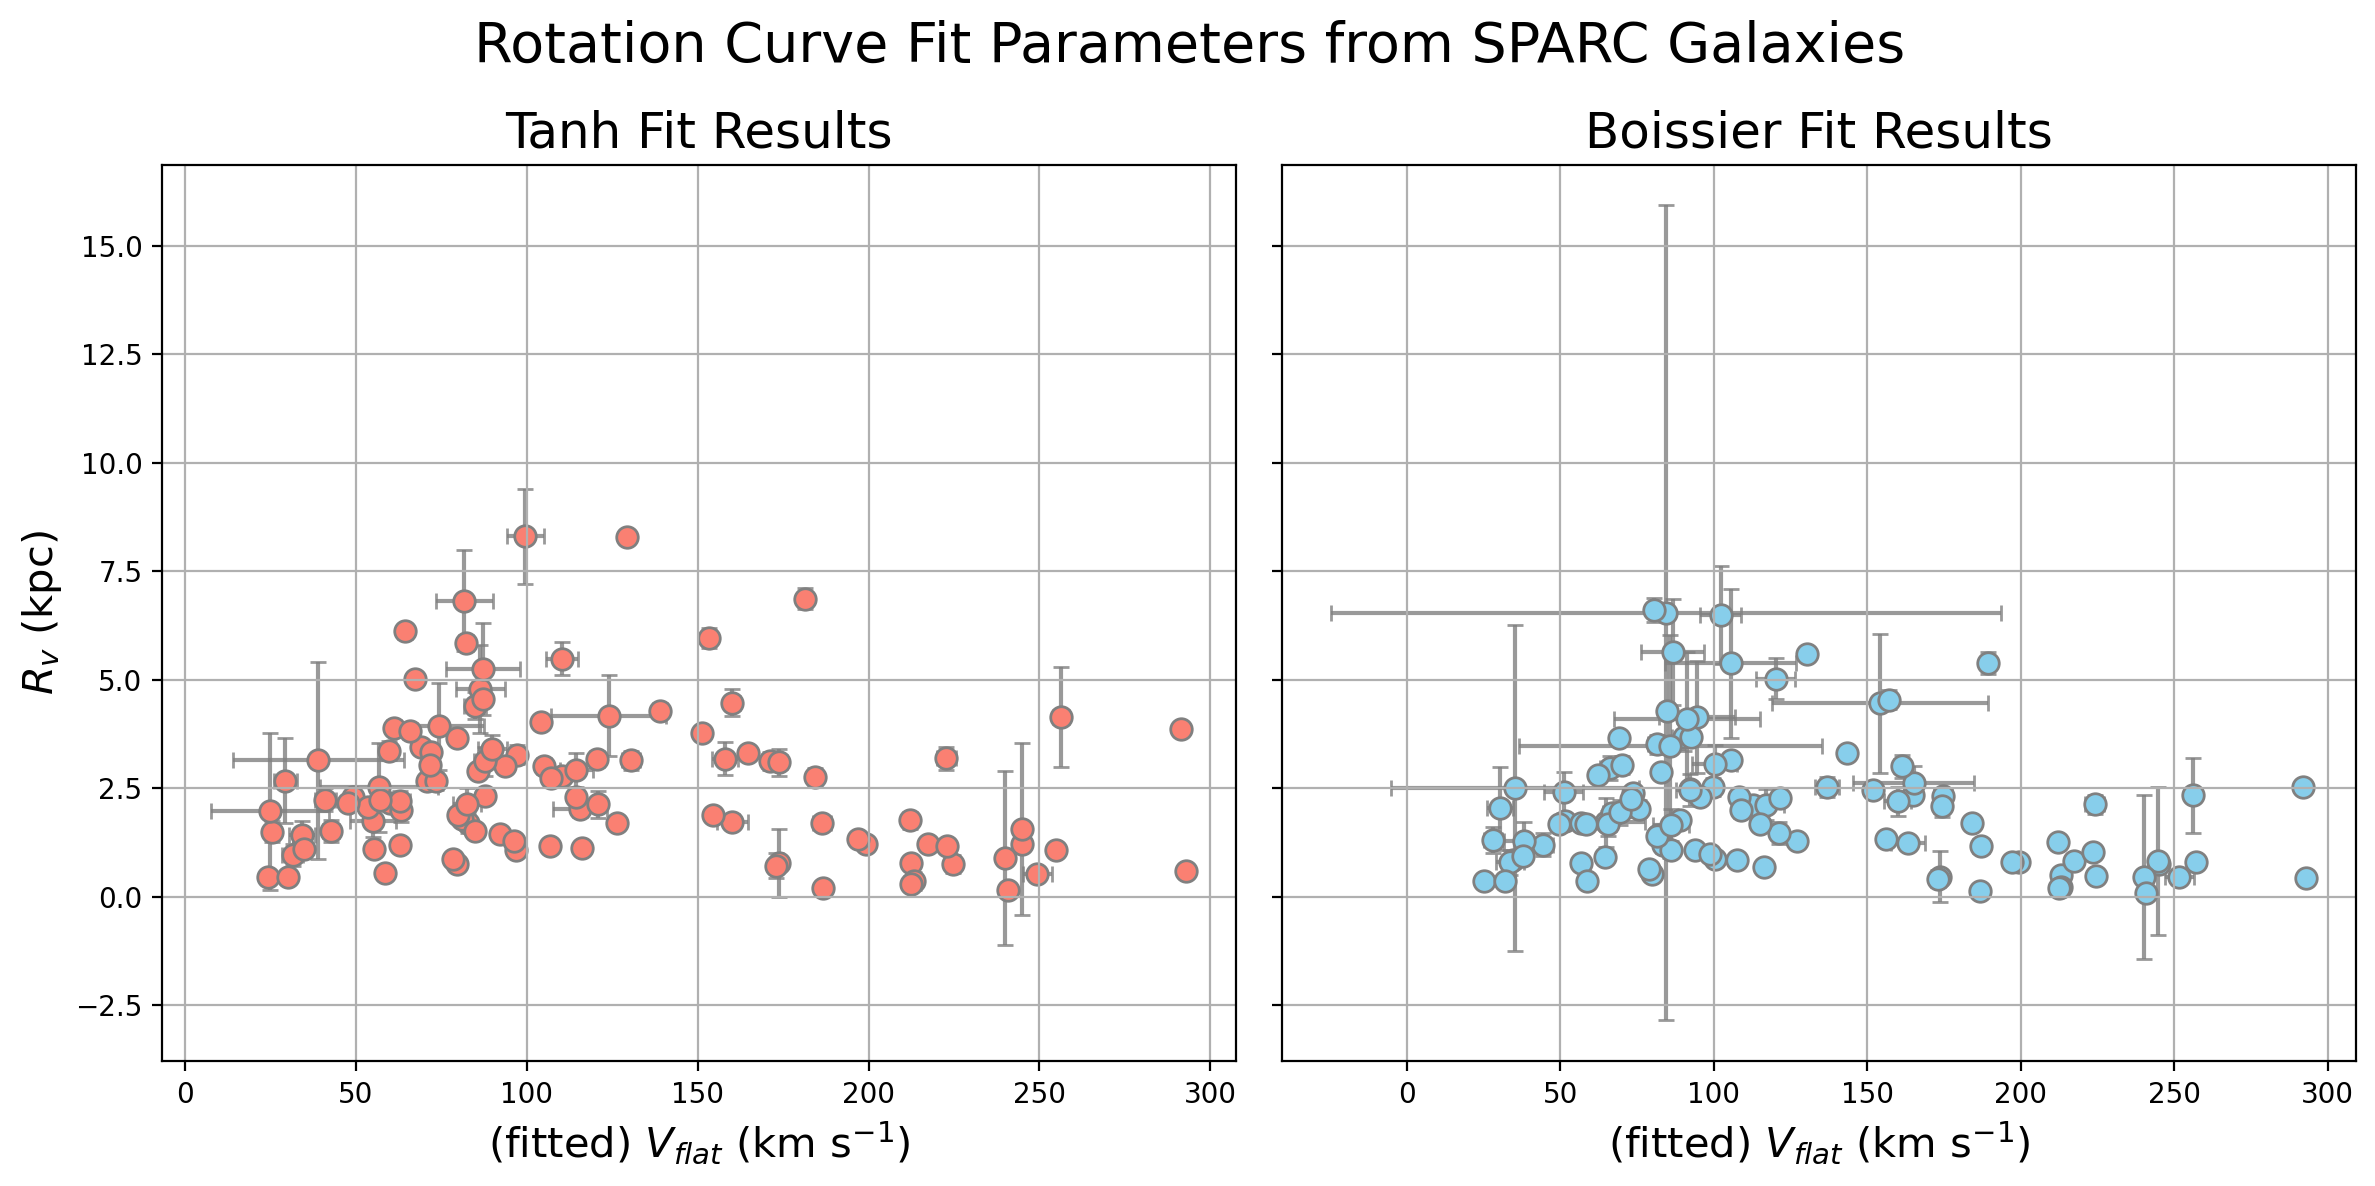

In [8]:
# Make plots of Rv vs v_rot for all galaxies from both fit types -- IMPORTANT: v_flat here is the fitted v_rot, not SPARC published v_flat

# index results by galaxy name
tanh_map = {p[0]: p for p in param_list_SPARC_tanh}
bois_map = {p[0]: p for p in param_list_SPARC_boissier}
sparc_idx = (sparc.drop_duplicates('Name').set_index('Name'))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, sharey=True, facecolor='w')
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map: 
        continue
    _, vrot_t, vrot_t_err, rvt, rvt_err = tanh_map[galaxy]
    if np.isfinite(rvt) and np.isfinite(vrot_t) and np.isfinite(rvt_err) and np.isfinite(vrot_t_err) and rvt>0 and vrot_t>0 and rvt_err>0 and vrot_t_err>0:
        ax.scatter(vrot_t, rvt, s=60, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(vrot_t, rvt, xerr=vrot_t_err, yerr=rvt_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.set_ylabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_xlabel(r"(fitted) $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title("Tanh Fit Results", fontsize=18)
ax.grid()

ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map: 
        continue
    _, vrot_b, vrot_b_err, rvb, rvb_err = bois_map[galaxy]
    if np.isfinite(rvb) and np.isfinite(vrot_b) and np.isfinite(rvb_err) and np.isfinite(vrot_b_err) and rvb>0 and vrot_b>0 and rvb_err>0 and vrot_b_err>0:
        ax.scatter(vrot_b, rvb, s=60, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(vrot_b, rvb, xerr=vrot_b_err, yerr=rvb_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.set_xlabel(r"(fitted) $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title("Boissier Fit Results", fontsize=18)
ax.grid()
plt.suptitle("Rotation Curve Fit Parameters from SPARC Galaxies", fontsize=20)
plt.tight_layout()
#plt.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/SPARC_Rv_vs_Vflat.png')
plt.show()

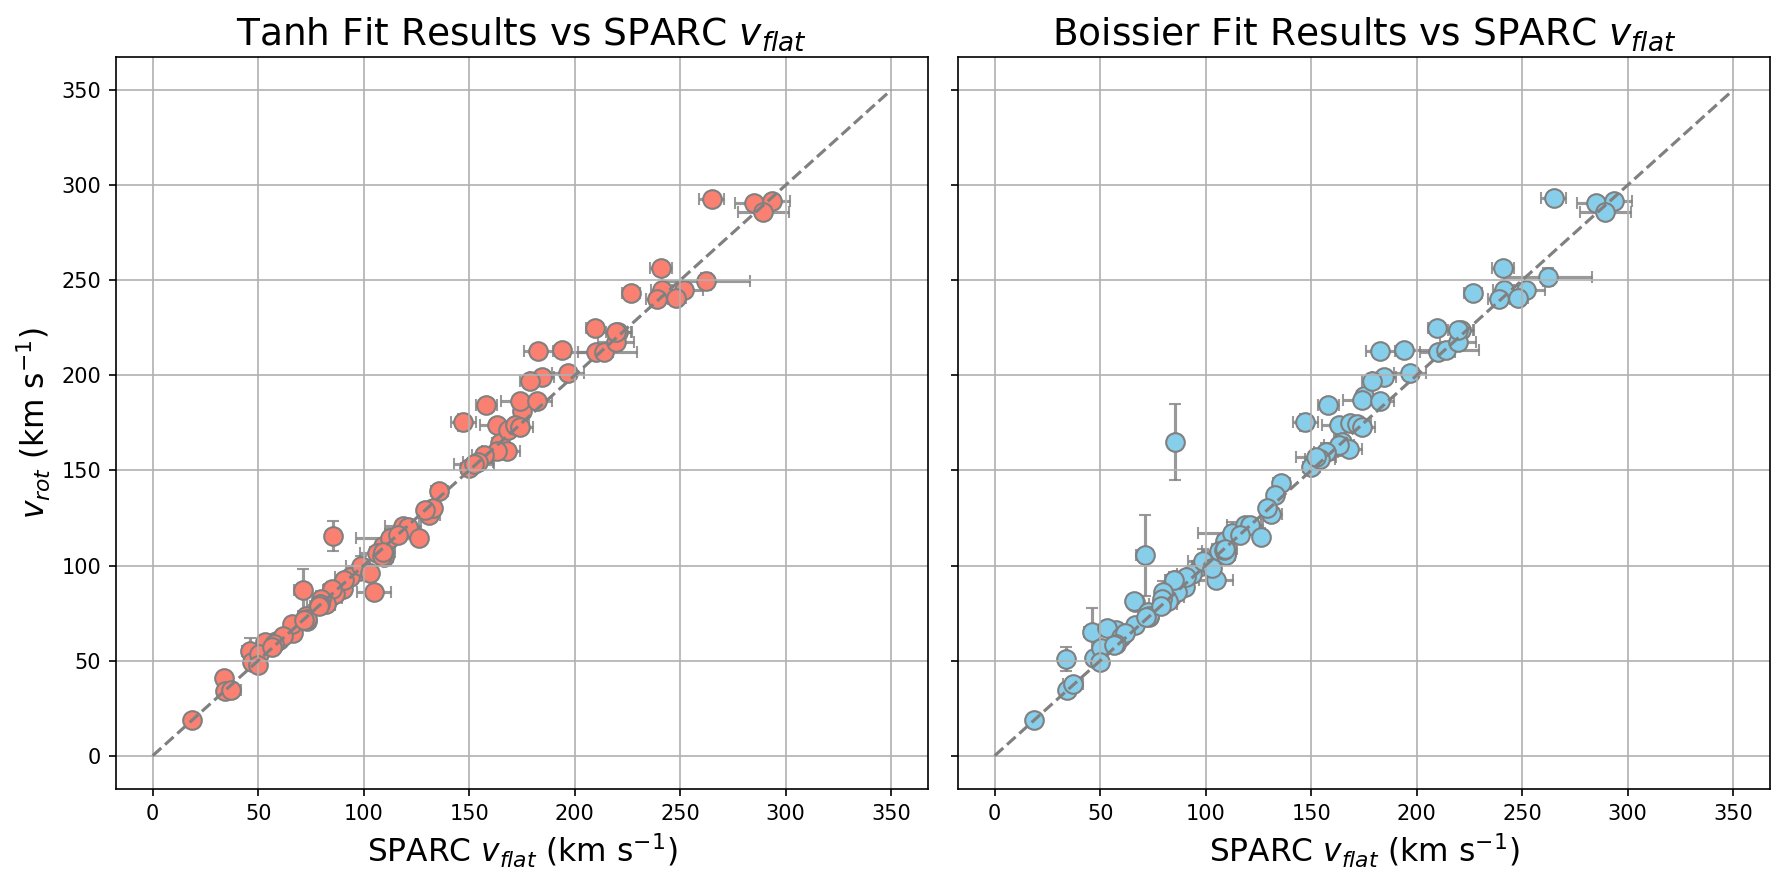

In [9]:
# Make plots of v_rot from both fits vs SPARC v_flat sorted so they lie on y=x line

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=150, sharey=True, facecolor='w')
ax = axes[0]
for i, galaxy in enumerate(gab_names_finc):
    if galaxy not in tanh_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_t, vrot_t_err, _, _ = tanh_map[galaxy]
    if np.isfinite(vflat) and np.isfinite(vrot_t) and np.isfinite(vflat_err) and np.isfinite(vrot_t_err) and vflat>0 and vrot_t>0 and vflat_err>0 and vrot_t_err>0:
        ax.scatter(vflat, vrot_t, s=80, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(vflat, vrot_t, xerr=vflat_err, yerr=vrot_t_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.plot([0, 350], [0, 350], ls='--', c='grey')
ax.set_ylabel(r'$v_{rot}$ (km s$^{-1}$)', fontsize=15)
ax.set_xlabel(r'SPARC $v_{flat}$ (km s$^{-1}$)', fontsize=15)
ax.set_title('Tanh Fit Results vs SPARC $v_{flat}$', fontsize=18)
ax.grid()
ax = axes[1]
for i, galaxy in enumerate(gab_names_finc):
    if galaxy not in bois_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_b, vrot_b_err, _, _ = bois_map[galaxy]
    if np.isfinite(vflat) and np.isfinite(vrot_b) and np.isfinite(vflat_err) and np.isfinite(vrot_b_err) and vflat>0 and vrot_b>0 and vflat_err>0 and vrot_b_err>0:
        ax.scatter(vflat, vrot_b, s=80, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(vflat, vrot_b, xerr=vflat_err, yerr=vrot_b_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.plot([0, 350], [0, 350], ls='--', c='grey')
ax.set_xlabel(r'SPARC $v_{flat}$ (km s$^{-1}$)', fontsize=15)
ax.set_title('Boissier Fit Results vs SPARC $v_{flat}$', fontsize=18)
ax.grid()
plt.tight_layout()
plt.show()


In [10]:
names = [n for n in gab_names_finc if n in sparc_idx.index and n in tanh_map and n in bois_map]
bad_vflat = [n for n in names if not (np.isfinite(sparc_idx.at[n,'Vflat']) and sparc_idx.at[n,'Vflat']>0)]
names = [n for n in names if n not in bad_vflat]
rows = []

for n in names:
    _, vt, vt_e, Rt, Rt_e = tanh_map[n]
    _, vb, vb_e, Rb, Rb_e = bois_map.get(n, (np.nan,np.nan,np.nan,np.nan,np.nan))
    vf, evf = float(sparc_idx.at[n,'Vflat']), float(sparc_idx.at[n,'e_Vflat'])
    rows.append((n, vf, evf, vt, vt_e, Rt, Rt_e, vb, vb_e, Rb, Rb_e))

tab = pd.DataFrame(rows, columns=[
    'Name','Vflat','e_Vflat','vrot_t','e_vrot_t','Rv_t','e_Rv_t','vrot_b','e_vrot_b','Rv_b','e_Rv_b'
])

# residuals vs SPARC
tab['Delta_t'] = np.abs(tab['vrot_t'] - tab['Vflat'])
tab['Delta_b'] = np.abs(tab['vrot_b'] - tab['Vflat'])

In [11]:
print("Tanh worst |v_rot - V_flat|:")
print(tab.sort_values('Delta_t', ascending=False).head(10)[['Name','Vflat','vrot_t','Delta_t']])

print("\nBoissier worst |v_rot - V_flat|:")
print(tab.sort_values('Delta_b', ascending=False).head(10)[['Name','Vflat','vrot_b','Delta_b']])

Tanh worst |v_rot - V_flat|:
        Name  Vflat      vrot_t    Delta_t
25   NGC2976   85.4  115.449720  30.049720
61  UGC02916  182.7  212.558959  29.858959
62  UGC02953  264.9  292.946644  28.046644
43   NGC4138  147.3  175.229223  27.929223
42   NGC4100  158.2  184.192993  25.992993
15   NGC0247  104.9   85.825287  19.074713
46   NGC5033  194.2  213.173937  18.973937
47   NGC5055  179.0  197.061874  18.061874
88  UGC09133  226.8  243.458935  16.658935
76  UGC06818   71.2   87.143388  15.943388

Boissier worst |v_rot - V_flat|:
        Name  Vflat      vrot_b    Delta_b
25   NGC2976   85.4  165.045822  79.645822
76  UGC06818   71.2  105.447800  34.247800
61  UGC02916  182.7  212.561953  29.861953
62  UGC02953  264.9  293.005370  28.105370
43   NGC4138  147.3  175.229837  27.929837
42   NGC4100  158.2  184.174649  25.974649
46   NGC5033  194.2  213.173952  18.973952
1     DDO064   46.1   64.868370  18.768370
47   NGC5055  179.0  197.105927  18.105927
12  KK98-251   33.7   50.993640  1

In [12]:
# absolute thresholds
sus_t_abs = tab[(tab['Rv_t'] > 6) & (tab['vrot_t'] > 150)]
sus_b_abs = tab[(tab['Rv_b'] > 4) & (tab['vrot_b'] > 150)]
print("Tanh high Rv & high v_rot:\n", sus_t_abs[['Name', 'Rv_t', 'e_Rv_t','vrot_t', 'e_vrot_t', 'Delta_t']])
print("Boissier high Rv & high v_rot:\n", sus_b_abs[['Name', 'Rv_b', 'e_Rv_b', 'vrot_b', 'e_vrot_b', 'Delta_b']])

# percentile
# qt_R, qt_V = tab['Rv_t'].quantile(0.95), tab['vrot_t'].quantile(0.95)
# qb_R, qb_V = tab['Rv_b'].quantile(0.95), tab['vrot_b'].quantile(0.95)
# sus_t_pct = tab[(tab['Rv_t'] >= qt_R) & (tab['vrot_t'] >= qt_V)]
# sus_b_pct = tab[(tab['Rv_b'] >= qb_R) & (tab['vrot_b'] >= qb_V)]
# print("Tanh top-5% both:", sus_t_pct[['Name','Rv_t','vrot_t']])
# print("Boissier top-5% both:", sus_b_pct[['Name','Rv_b','vrot_b']])

Tanh high Rv & high v_rot:
           Name      Rv_t    e_Rv_t      vrot_t  e_vrot_t   Delta_t
6  ESO079-G014  6.863583  0.239379  181.485547  1.621227  6.485547
Boissier high Rv & high v_rot:
            Name      Rv_b    e_Rv_b      vrot_b  e_vrot_b    Delta_b
6   ESO079-G014  5.387990  0.248535  189.341620  2.419697  14.341620
87     UGC09037  4.544098  0.219209  157.183482  2.157375   4.883482


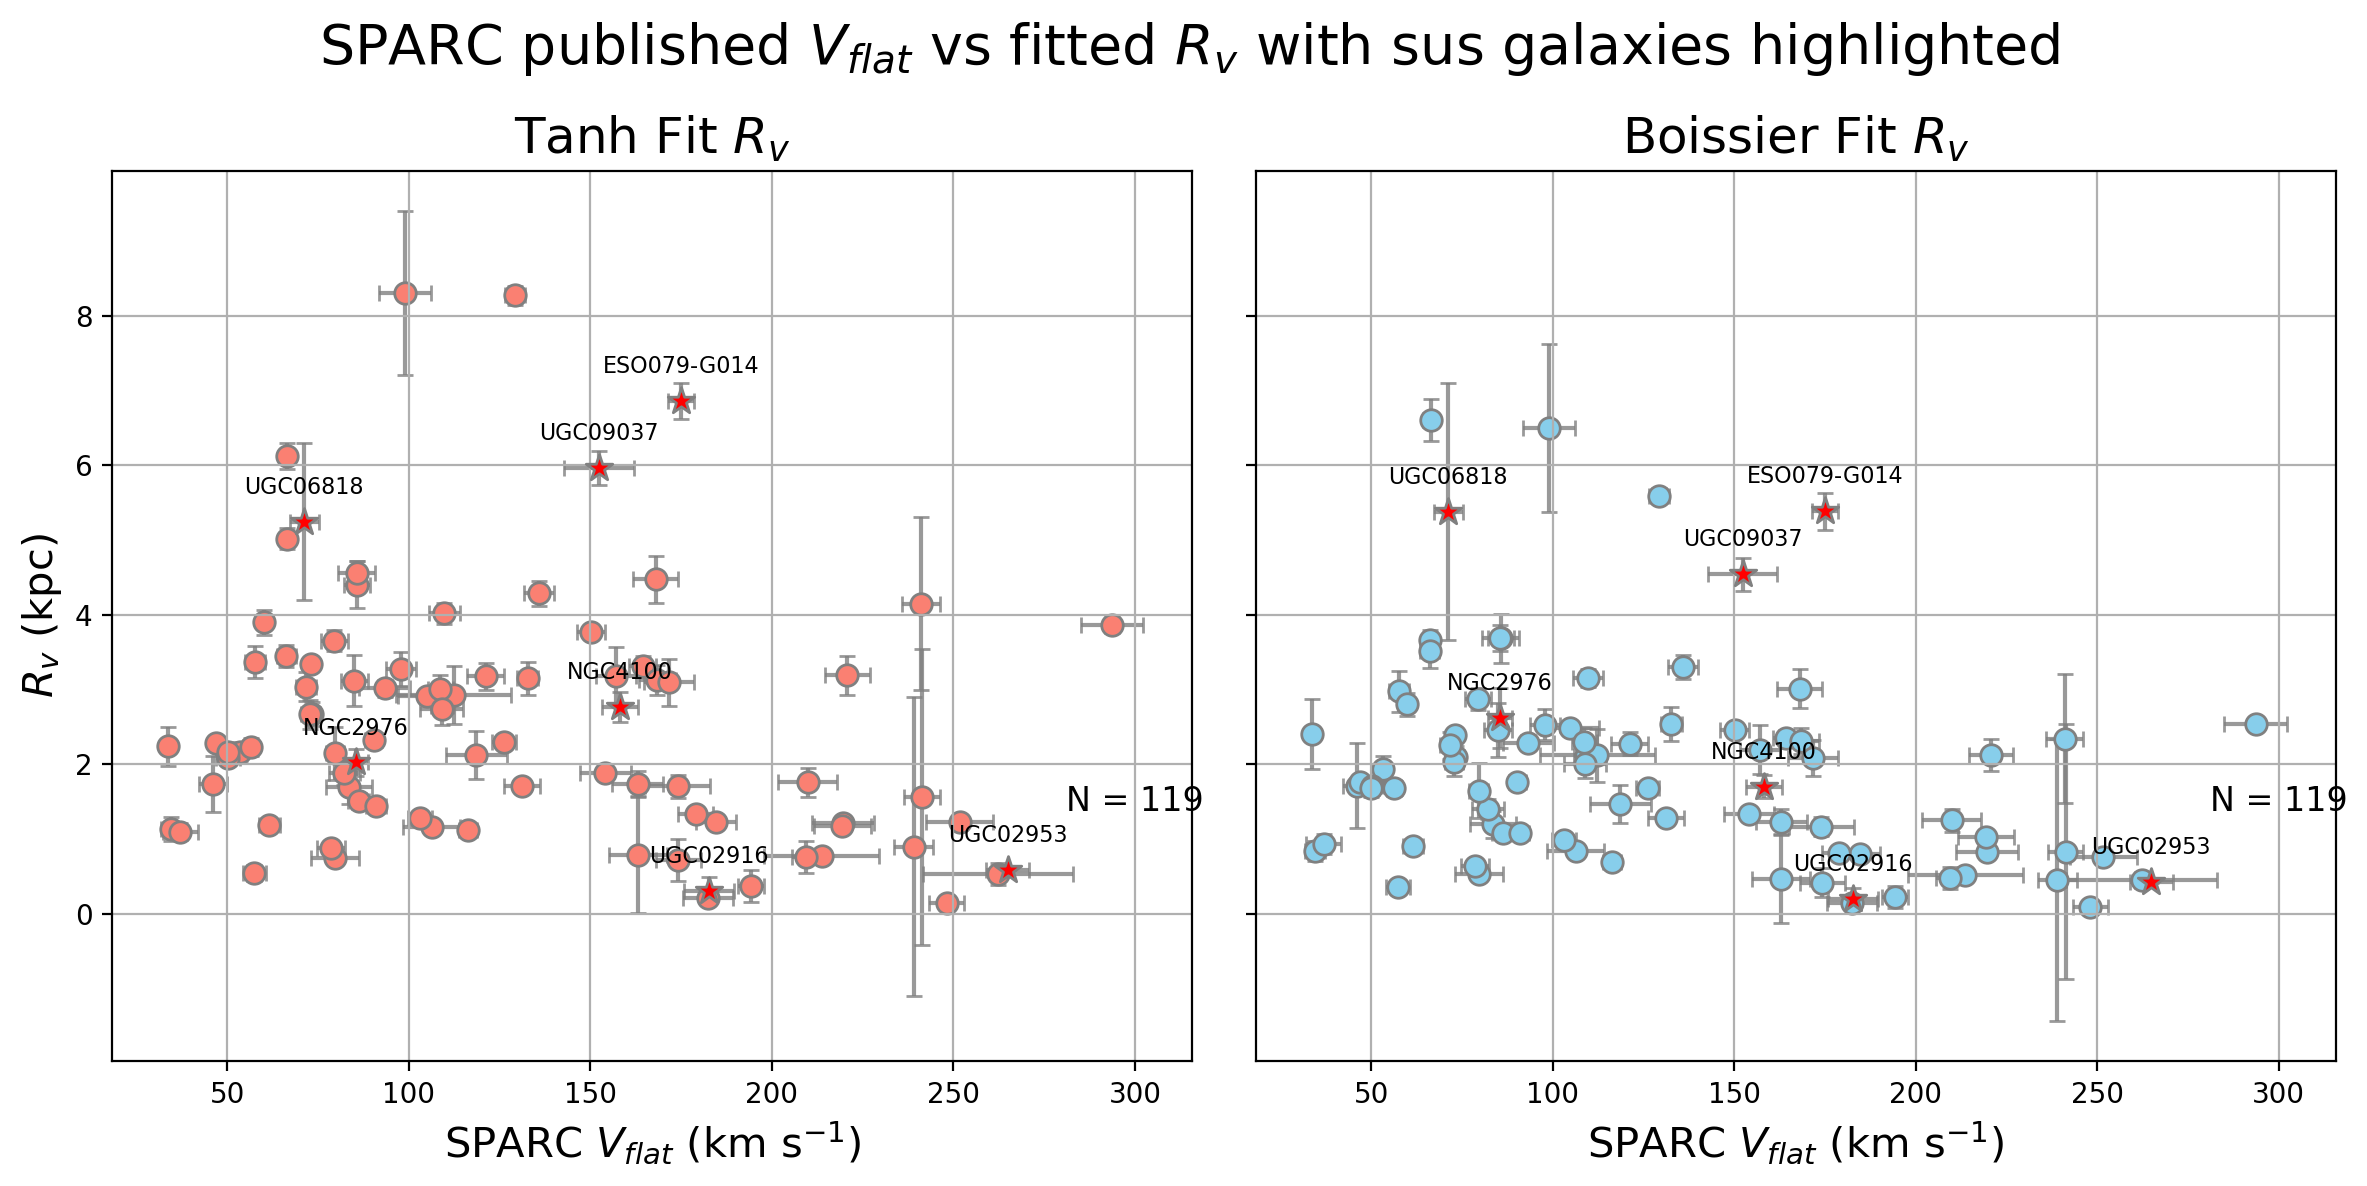

In [13]:
# Make v_flat vs R_v plots using the SPARC published v_flat instead. Highlight suspicious galaxies with annotated name next to point
# IMPORTANT: here v_flat is from SPARC, not the fitted v_rot

# index sus galaxies
sus_t = set(sus_t_abs['Name'].tolist())
sus_b = set(sus_b_abs['Name'].tolist())
sus_all = sus_t | sus_b

# Add sus galaxies that have very high Delta_t or Delta_b even if they don't have high Rv and v_rot
sus_t_extra = set(tab[tab['Delta_t'] > 25]['Name'].tolist())
sus_b_extra = set(tab[tab['Delta_b'] > 25]['Name'].tolist())
sus_all_extra = sus_all | sus_t_extra | sus_b_extra

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, sharey=True, facecolor='w')
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_t, vrot_t_err, rvt, rvt_err = tanh_map[galaxy]
    if np.isfinite(rvt) and np.isfinite(vflat) and np.isfinite(rvt_err) and np.isfinite(vflat_err) and rvt>0 and vflat>0 and rvt_err>0 and vflat_err>0:
        if galaxy in sus_all_extra:
            ax.scatter(vflat, rvt, s=100, label=galaxy, c='red', edgecolors='grey', marker='*', zorder=5)
            ax.annotate(galaxy, (vflat, rvt), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(vflat, rvt, s=60, label=galaxy, c='salmon', edgecolors='grey')
        ax.errorbar(vflat, rvt, xerr=vflat_err, yerr=rvt_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.annotate(f"N = {len(gab_names_finc)}", (300, 1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, color='k')
ax.set_ylabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title(r"Tanh Fit $R_v$", fontsize=18)
ax.grid()
ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in sparc_idx.index:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_b, vrot_b_err, rvb, rvb_err = bois_map[galaxy]
    if np.isfinite(rvb) and np.isfinite(vflat) and np.isfinite(rvb_err) and np.isfinite(vflat_err) and rvb>0 and vflat>0 and rvb_err>0 and vflat_err>0:
        if galaxy in sus_all_extra:
            ax.scatter(vflat, rvb, s=100, label=galaxy, c='red', edgecolors='grey', marker='*', zorder=5)
            ax.annotate(galaxy, (vflat, rvb), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(vflat, rvb, s=60, label=galaxy, c='skyblue', edgecolors='grey')
        ax.errorbar(vflat, rvb, xerr=vflat_err, yerr=rvb_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.annotate(f"N = {len(gab_names_finc)}", (300, 1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, color='k')
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title(r"Boissier Fit $R_v$", fontsize=18)
ax.grid()
plt.suptitle(r"SPARC published $V_{flat}$ vs fitted $R_{v}$ with sus galaxies highlighted", fontsize=20)
plt.tight_layout()
#plt.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/SPARC_Rv_vs_Vflat_using_SPARC_vflat.png')
plt.show()




In [14]:
sus_all = sus_all if 'sus_all' in globals() else set()

sus_t_fit = set(tab[tab['Delta_t'] > 15]['Name'].tolist())
sus_b_fit = set(tab[tab['Delta_b'] > 15]['Name'].tolist())
sus_t_error = set(tab[tab['e_Rv_t'] >  1]['Name'].tolist())
sus_b_error = set(tab[tab['e_Rv_b'] >  1]['Name'].tolist())
sus_t_rv = set(tab[tab['Rv_t'] < 0.5]['Name'].tolist())
sus_b_rv = set(tab[tab['Rv_b'] < 0.5]['Name'].tolist())

sus_from_maps = set()
for g in gab_names_finc:
    if g in tanh_map:
        _, _, _, rvt, rvt_err = tanh_map[g]
        if np.isfinite(rvt_err) and (rvt_err > 1): sus_from_maps.add(g)
        if np.isfinite(rvt) and (rvt < 0.5): sus_from_maps.add(g)
    if g in bois_map:
        _, _, _, rvb, rvb_err = bois_map[g]
        if np.isfinite(rvb_err) and (rvb_err > 1): sus_from_maps.add(g)
        if np.isfinite(rvb) and (rvb < 0.5): sus_from_maps.add(g)
sus_all_fit = sus_all | sus_t_fit | sus_b_fit | sus_t_error | sus_b_error | sus_t_rv | sus_b_rv | sus_from_maps
print("Galaxies excluded from fit:\n", sus_all_fit)

Galaxies excluded from fit:
 {'NGC2841', 'NGC4068', 'NGC5055', 'NGC4100', 'NGC4138', 'NGC6674', 'CamB', 'NGC0289', 'UGC09037', 'NGC2976', 'NGC5033', 'UGC09133', 'UGCA281', 'UGC02953', 'ESO079-G014', 'UGC05005', 'PGC51017', 'NGC3109', 'NGC3992', 'UGC06787', 'UGC08699', 'UGC06818', 'F565-V2', 'NGC5371', 'UGC04483', 'UGC02916', 'NGC7331', 'DDO064', 'UGC02455', 'UGC02885', 'UGC07690', 'NGC5005', 'NGC0247', 'UGC06973', 'UGC07577', 'UGC03546', 'KK98-251', 'UGC05750', 'NGC4389'}


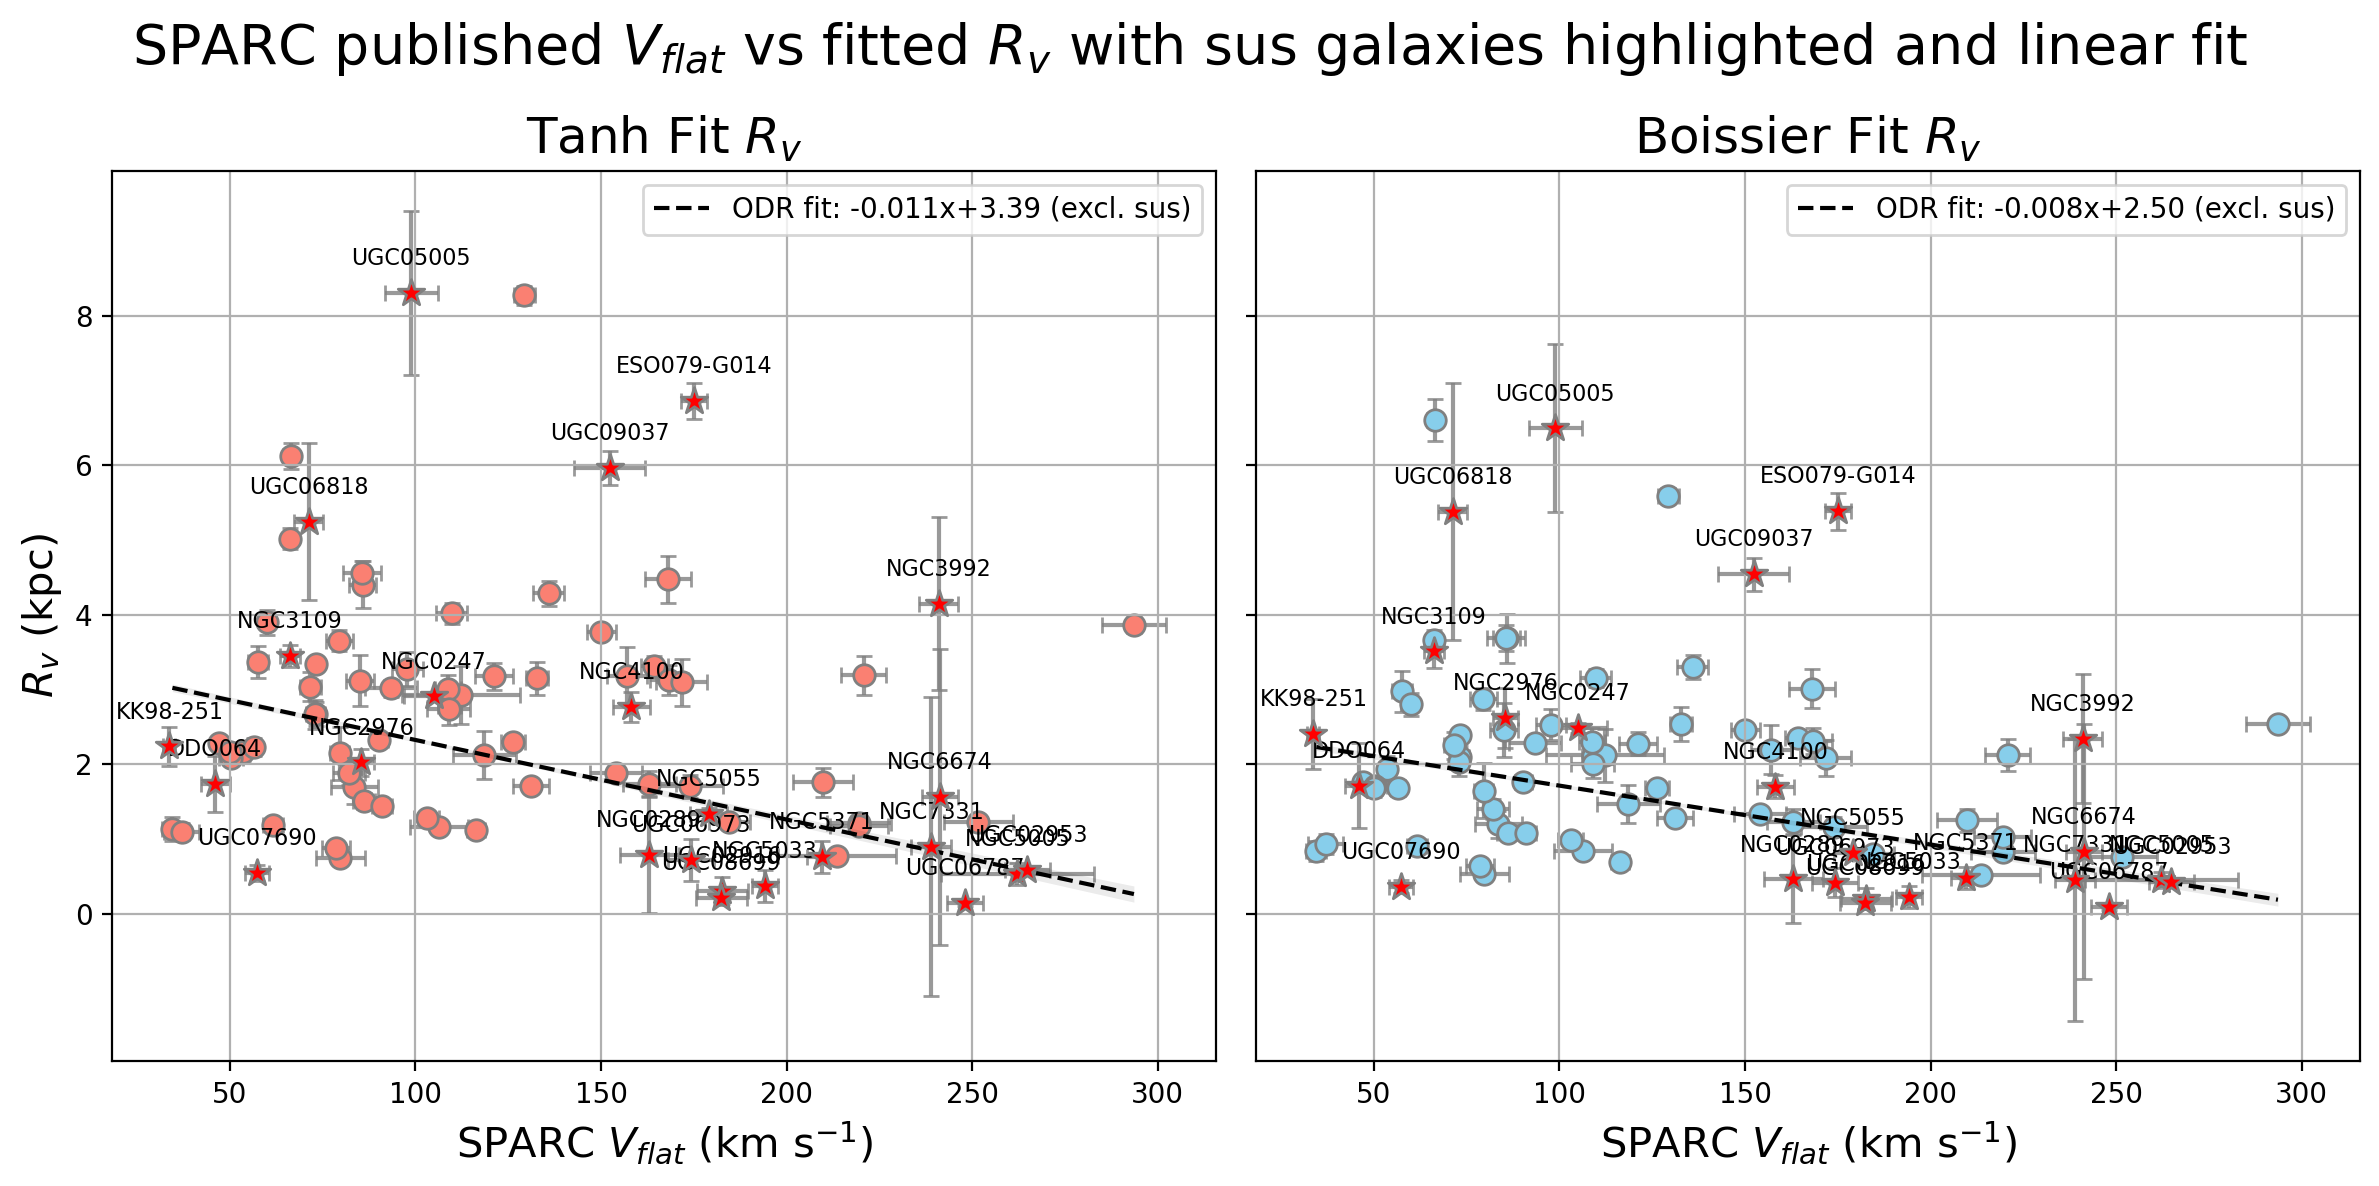

In [15]:
# Fit R_v vs v_flat with a line, excluding sus galaxies, plot the fit with data

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, sharey=True, facecolor='w')

# TANH
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in sparc_idx.index:
        continue
    vflat     = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_t, vrot_t_err, rvt, rvt_err = tanh_map[galaxy]
    if np.isfinite(rvt) and np.isfinite(vflat) and np.isfinite(rvt_err) and np.isfinite(vflat_err) and rvt>0 and vflat>0 and rvt_err>0 and vflat_err>0:
        if galaxy in sus_all_fit:
            ax.scatter(vflat, rvt, s=100, c='red', edgecolors='grey', marker='*', zorder=5)
            ax.annotate(galaxy, (vflat, rvt), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(vflat, rvt, s=60, c='salmon', edgecolors='grey')
        ax.errorbar(vflat, rvt, xerr=vflat_err, yerr=rvt_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)

mask = (~tab['Name'].isin(sus_all_fit) &
        np.isfinite(tab['Rv_t']) & (tab['Rv_t'] > 0) &
        np.isfinite(tab['e_Rv_t']) & (tab['e_Rv_t'] > 0) &
        np.isfinite(tab['Vflat']) & (tab['Vflat'] > 0) &
        np.isfinite(tab['e_Vflat']) & (tab['e_Vflat'] > 0))

x  = tab.loc[mask, 'Vflat'].to_numpy()
sx = tab.loc[mask, 'e_Vflat'].to_numpy()
y  = tab.loc[mask, 'Rv_t'].to_numpy()
sy = tab.loc[mask, 'e_Rv_t'].to_numpy()

lin  = odr.Model(lambda B, x: B[0] + B[1]*x)
data = odr.RealData(x, y, sx=sx, sy=sy)
beta0 = np.polyfit(x, y, 1)[::-1]
out   = odr.ODR(data, lin, beta0=beta0).run()
a, b  = out.beta
cov   = out.cov_beta

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = a + b*x_fit
ax.plot(x_fit, y_fit, ls='--', c='black', label=f'ODR fit: {b:.3f}x+{a:.2f} (excl. sus)')
sigma = np.sqrt(cov[0,0] + x_fit**2*cov[1,1] + 2*x_fit*cov[0,1])
ax.fill_between(x_fit, y_fit-1.96*sigma, y_fit+1.96*sigma, color='k', alpha=0.08, lw=0)
ax.legend()
ax.set_ylabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title(r"Tanh Fit $R_v$", fontsize=18)
ax.grid()

# BOISSIER
ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in sparc_idx.index:
        continue
    vflat     = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, vrot_b, vrot_b_err, rvb, rvb_err = bois_map[galaxy]
    if np.isfinite(rvb) and np.isfinite(vflat) and np.isfinite(rvb_err) and np.isfinite(vflat_err) and rvb>0 and vflat>0 and rvb_err>0 and vflat_err>0:
        if galaxy in sus_all_fit:
            ax.scatter(vflat, rvb, s=100, c='red', edgecolors='grey', marker='*', zorder=5)
            ax.annotate(galaxy, (vflat, rvb), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='k')
        else:
            ax.scatter(vflat, rvb, s=60, c='skyblue', edgecolors='grey')
        ax.errorbar(vflat, rvb, xerr=vflat_err, yerr=rvb_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)

mask = (~tab['Name'].isin(sus_all_fit) &
        np.isfinite(tab['Rv_b']) & (tab['Rv_b'] > 0) &
        np.isfinite(tab['e_Rv_b']) & (tab['e_Rv_b'] > 0) &
        np.isfinite(tab['Vflat']) & (tab['Vflat'] > 0) &
        np.isfinite(tab['e_Vflat']) & (tab['e_Vflat'] > 0))

x  = tab.loc[mask, 'Vflat'].to_numpy()
sx = tab.loc[mask, 'e_Vflat'].to_numpy()
y  = tab.loc[mask, 'Rv_b'].to_numpy()
sy = tab.loc[mask, 'e_Rv_b'].to_numpy()

lin  = odr.Model(lambda B, x: B[0] + B[1]*x)
data = odr.RealData(x, y, sx=sx, sy=sy)
beta0 = np.polyfit(x, y, 1)[::-1]
out   = odr.ODR(data, lin, beta0=beta0).run()
a, b  = out.beta
cov   = out.cov_beta

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = a + b*x_fit
ax.plot(x_fit, y_fit, ls='--', c='black', label=f'ODR fit: {b:.3f}x+{a:.2f} (excl. sus)')
sigma = np.sqrt(cov[0,0] + x_fit**2*cov[1,1] + 2*x_fit*cov[0,1])
ax.fill_between(x_fit, y_fit-1.96*sigma, y_fit+1.96*sigma, color='k', alpha=0.08, lw=0)
ax.legend()

ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title(r"Boissier Fit $R_v$", fontsize=18)
ax.grid()

plt.suptitle(r"SPARC published $V_{flat}$ vs fitted $R_{v}$ with sus galaxies highlighted and linear fit", fontsize=20)
plt.tight_layout()
plt.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/SPARC_Rv_vs_Vflat_with_fit_excl_sus.png')
plt.show()

In [16]:
# print galaxy name of galaxies and v_flat with highest v_flat out of the non-sus ones
non_sus_galaxies = [n for n in names if n not in sus_all_fit]
non_sus_tab = tab[tab['Name'].isin(non_sus_galaxies)]
top5_tanh = non_sus_tab.sort_values('vrot_t', ascending=False).head(5)
top5_boissier = non_sus_tab.sort_values('vrot_b', ascending=False).head(5)

print("Top 5 non-sus galaxies by v_rot from Tanh fit:")
print(top5_tanh[['Name', 'vrot_t', 'e_vrot_t', 'Vflat', 'e_Vflat']])
print("\nTop 5 non-sus galaxies by v_rot from Boissier fit:")
print(top5_boissier[['Name', 'vrot_b', 'e_vrot_b', 'Vflat', 'e_Vflat']])

Top 5 non-sus galaxies by v_rot from Tanh fit:
        Name      vrot_t  e_vrot_t  Vflat  e_Vflat
50   NGC5985  291.450788  0.936167  293.6      8.6
52   NGC6195  244.774929  1.288961  251.7      9.3
74  UGC06786  222.885436  0.430020  219.4      7.8
37   NGC3953  222.781037  2.811202  220.8      6.1
63  UGC03205  217.425644  0.533496  219.6      8.6

Top 5 non-sus galaxies by v_rot from Boissier fit:
        Name      vrot_b  e_vrot_b  Vflat  e_Vflat
50   NGC5985  291.825215  0.957687  293.6      8.6
52   NGC6195  244.918550  1.319360  251.7      9.3
37   NGC3953  224.061881  3.111111  220.8      6.1
74  UGC06786  223.652920  0.452007  219.4      7.8
63  UGC03205  217.477022  0.536165  219.6      8.6


I had to exclude galaxies with too low $R_v$ (fit is bad), too high difference between the fitted and published $v_{\mathrm{flat}}$ values, galaxies with inclination <40 and >79 (especially large inclination gave galaxies too edge on and with possible gas holes; chose 79 because there is a galaxy with Inc=79 that I checked and looks incredibly edge on, so I kinda have to remove that too). Also, remove galaxies with negative values, non zero errors, etc.  Also excluded galaxies with too high $R_v$ error (>1 kpc) which I checked and usually are galaxies which never reached the $v_\mathrm{flat}$ part of the rotation curve.

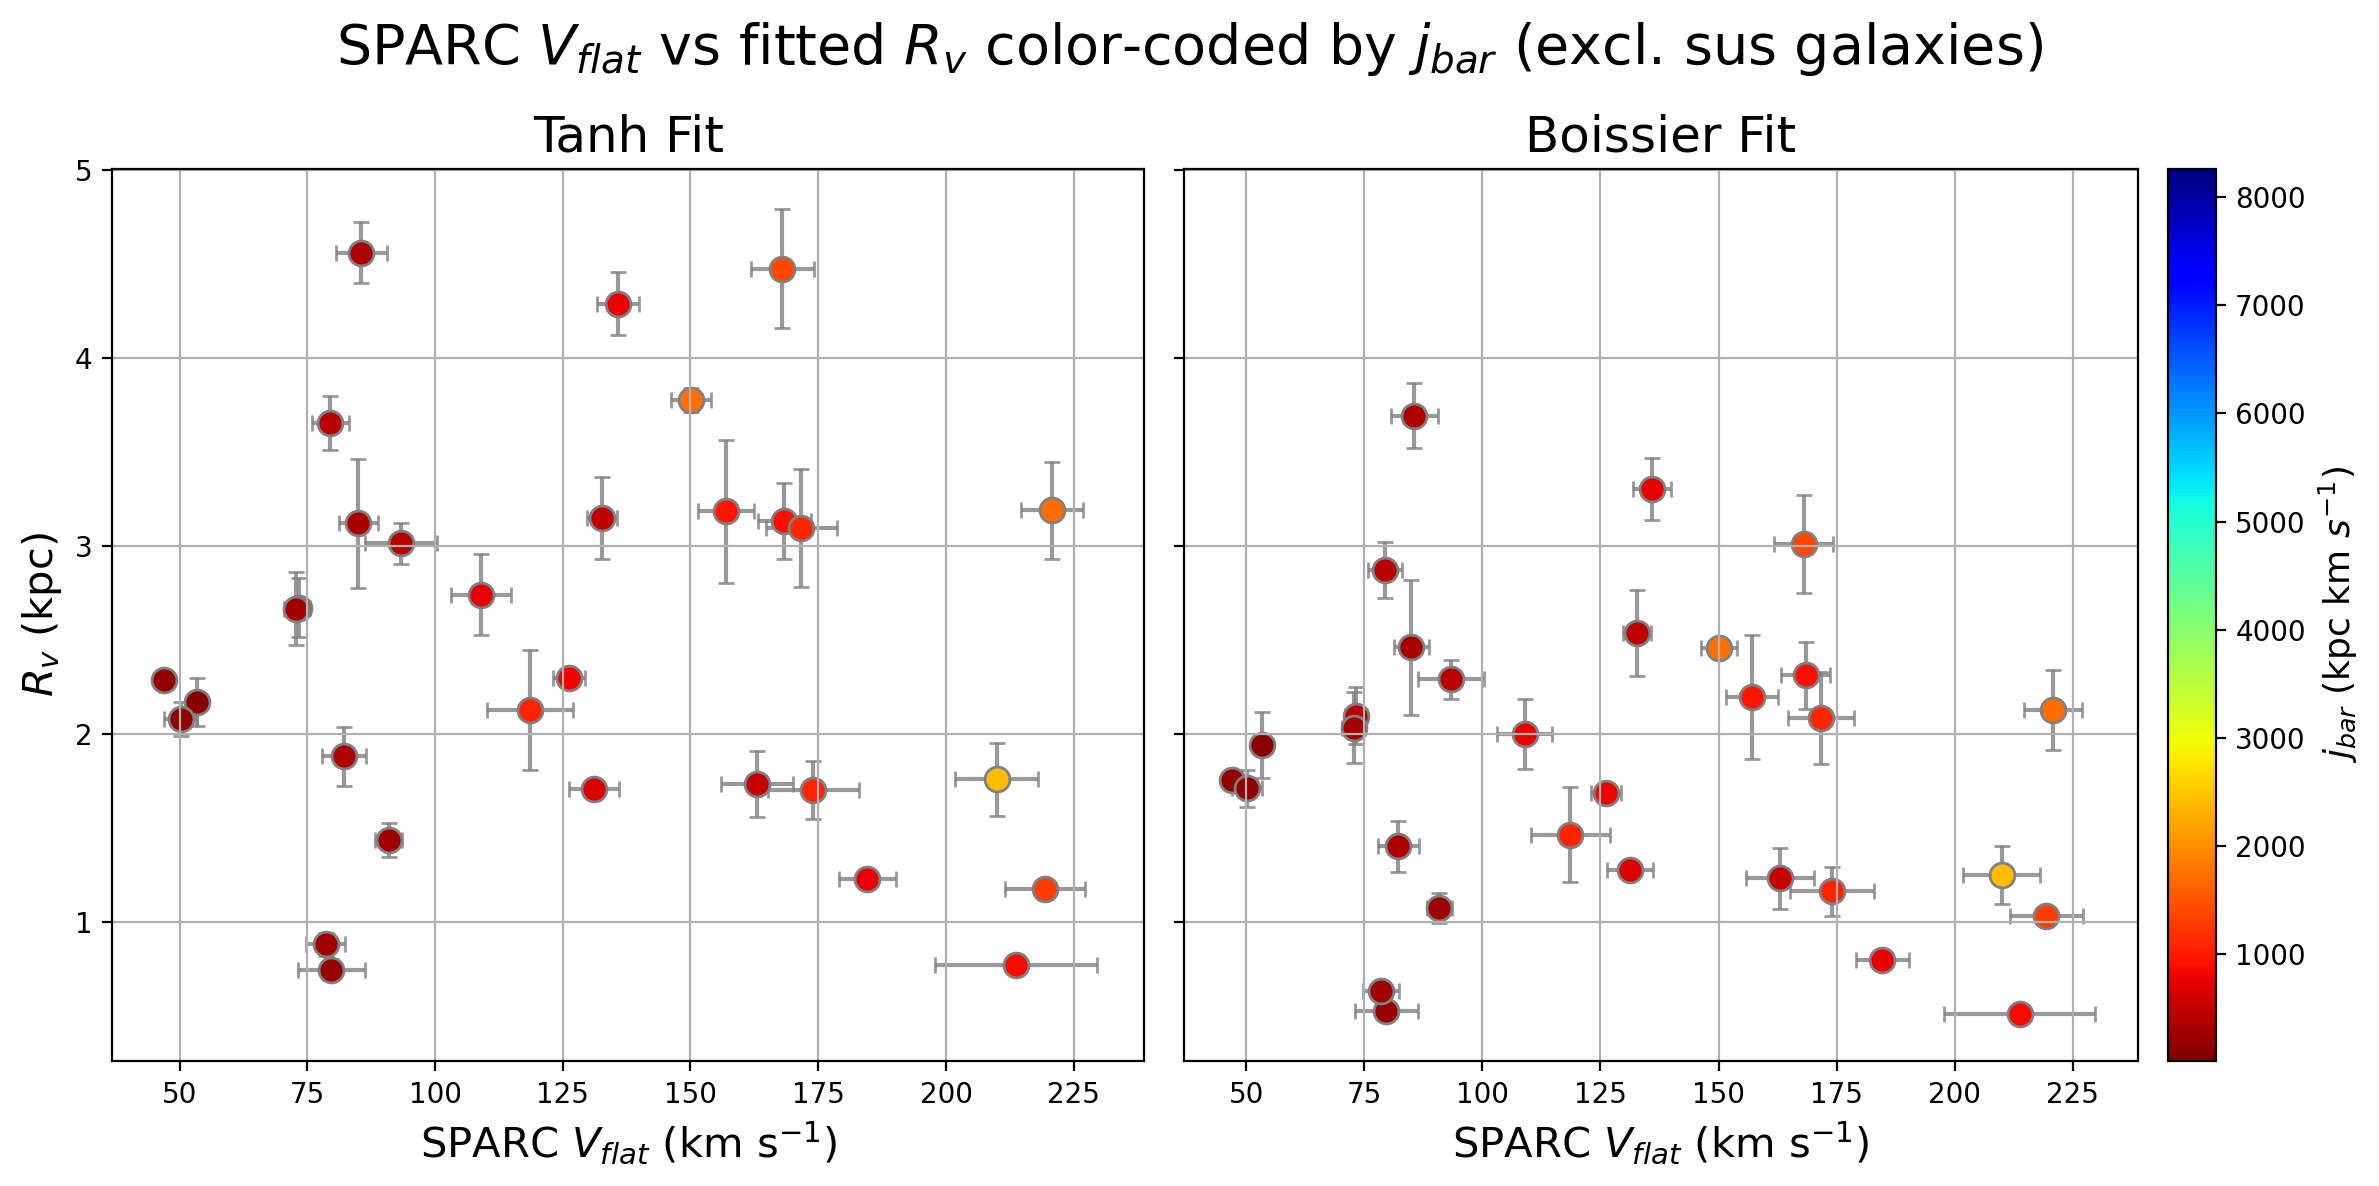

In [17]:
# plot again r_v vs SPARC v_flat but color-coded by j_bar, excluding sus galaxies

bary = pd.read_csv(datadir+'baryons1.csv')
bary_idx = bary.set_index('Name')
j_bar, j_bar_err, f_gas = bary['j'], bary['e_j'], bary['fgas']

def finite_pos(*vals):
    vals = np.asarray(vals, dtype=float)
    return np.isfinite(vals).all() and (vals > 0).all()

cmap = cm.jet_r

norm = mpl.colors.Normalize(vmin=np.nanmin(j_bar.values), vmax=np.nanmax(j_bar.values))
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200, sharey=True, facecolor='w')

# TANH
ax = axes[0]
for galaxy in gab_names_finc:
    if galaxy not in tanh_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, _, _, rvt, rvt_err = tanh_map[galaxy]
    jbar = bary_idx.at[galaxy, 'j']
    if finite_pos(rvt, vflat, jbar):
        color = cmap(norm(jbar))
        ax.scatter(vflat, rvt, s=80, label=galaxy, color=color, edgecolors='grey')
        ax.errorbar(vflat, rvt, xerr=vflat_err, yerr=rvt_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
ax.set_ylabel(r"$R_v$ (kpc)", fontsize=15)
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title("Tanh Fit", fontsize=18)
ax.grid()

# BOISSIER
ax = axes[1]
for galaxy in gab_names_finc:
    if galaxy not in bois_map or galaxy not in bary_idx.index or galaxy in sus_all_fit:
        continue
    vflat = sparc_idx.at[galaxy, 'Vflat']
    vflat_err = sparc_idx.at[galaxy, 'e_Vflat']
    _, _, _, rvb, rvb_err = bois_map[galaxy]
    jbar = bary_idx.at[galaxy, 'j']
    if finite_pos(rvb, vflat, jbar):
        color = cmap(norm(jbar))
        ax.scatter(vflat, rvb, s=80, label=galaxy, color=color, edgecolors='grey')
        ax.errorbar(vflat, rvb, xerr=vflat_err, yerr=rvb_err, fmt=' ', ecolor='grey', capsize=3, zorder=0, alpha=0.8)
    
ax.set_xlabel(r"SPARC $V_{flat}$ (km s$^{-1}$)", fontsize=15)
ax.set_title("Boissier Fit", fontsize=18)
ax.grid()
plt.suptitle(r"SPARC $V_{flat}$ vs fitted $R_{v}$ color-coded by $j_{bar}$ (excl. sus galaxies)", fontsize=20)

divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label(r"$j_{bar}$ (kpc km $s^{-1})$", fontsize=13)

plt.tight_layout()
plt.savefig(outdir+'rotcurves/SPARC_tanh_and_boissier_rotcurves/jbar_vs_Rv_excl_sus.png')
plt.show()